### **Problem Statement**

### **Predicting Customer Churn with Scikit-Learn Pipeline**

**Objective**

The objective of this project is to predict whether a customer is likely to leave a telecom company (customer churn) using machine learning.

A Scikit-Learn Pipeline API is developed for a production ready Machine Learning pipeline. Data preprocessing, training, hyper parameter tuning, evaluation and export for further deployment.

**Dataset**

Telco Customer Churn Dataset

**Models Used**

- Logistic Regression
- Random Forest Classifier

**Evaluation Metrics**

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

**Install Libraries**

In [ ]:
!pip install pandas numpy scikit-learn joblib seaborn matplotlib

**Install Libraries**

In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from sklearn.model_selection import GridSearchCV

import joblib

**Loading and Understanding the Dataset**

The Telco Customer Churn dataset contains customer demographic information, service subscriptions, and account details.

The target variable is Churn:
- Yes = Customer left the company
- No = Customer stayed with the company

**Load Dataset**

In [ ]:
df = pd.read_csv("/content/Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print(df.shape)

df.info()

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

In [ ]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


**Data Cleaning and Preprocessing**



In [ ]:
df.drop("customerID", axis=1, inplace=True)

df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [ ]:
df["Churn"] = df["Churn"].map({
    "Yes":1,
    "No":0
})

In [ ]:
print(df.isnull().sum())

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


**EDA**


Churn Distribution

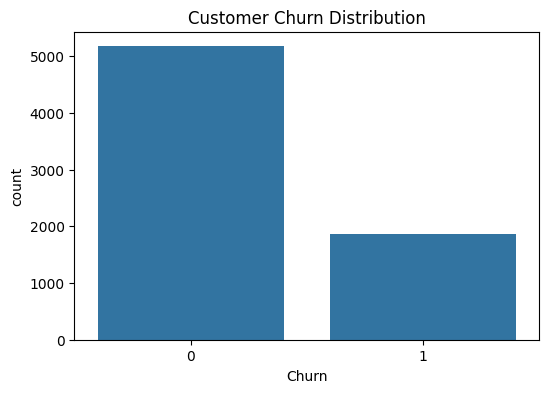

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="Churn",
    data=df
)

plt.title("Customer Churn Distribution")
plt.show()

Correlation Heatmap

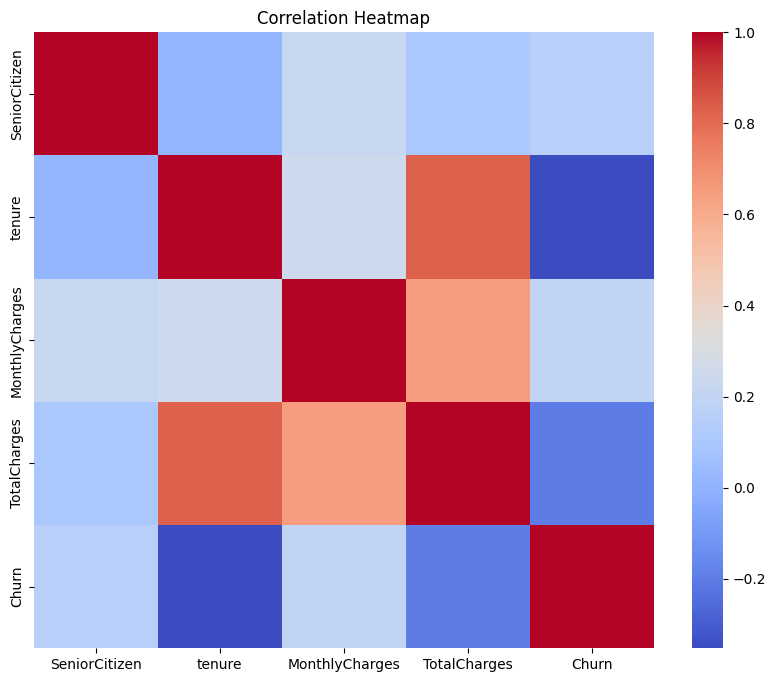

In [ ]:
numeric_cols = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_cols.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

**Features and Target**

In [ ]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

**Train Test Split**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Preprocessing Pipeline**

In [ ]:
numeric_features = X.select_dtypes(
    include=np.number
).columns

categorical_features = X.select_dtypes(
    exclude=np.number
).columns

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Logistic Regression Pipeline**



A complete machine learning pipeline is created to automate preprocessing and model training.

In [ ]:
log_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

log_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('classifier', LogisticRegression(max_iter=1000))])

**Predictions**

In [ ]:
y_pred_log = log_pipeline.predict(X_test)

**Evaluation**

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred_log
)

print("Accuracy:", accuracy)

print(
    classification_report(
        y_test,
        y_pred_log
    )
)

Accuracy: 0.8211497515968772
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



**Confusion Matrix**

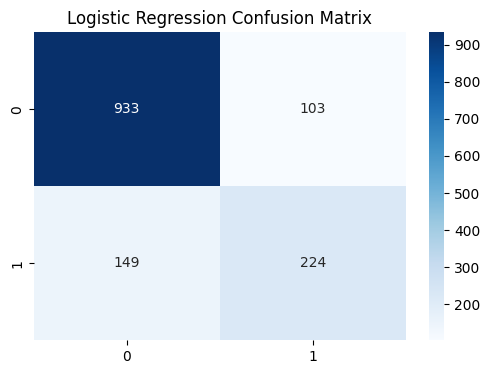

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_log
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

**Random Forest Pipeline**

In [ ]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                random_state=42
            )
        )
    ]
)

**Grid Search**

**Hyperparameter Tuning using GridSearchCV**


To find the best combination of parameters to improve the performance of the model, GridSearchCV was employed.


In [ ]:
param_grid = {
    "classifier__n_estimators":[100,200],
    "classifier__max_depth":[5,10,None]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid_search.fit(
    X_train,
    y_train
)

GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('e...
                                                                         Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [5, 10, None],
                         'classifier__n_estimators': [100, 200]},
             scoring='accuracy')

**Best Parameters**

In [ ]:
print(
    "Best Parameters:",
    grid_search.best_params_
)

Best Parameters: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}


**Best Model Evaluation**

In [ ]:
best_model = grid_search.best_estimator_

y_pred_rf = best_model.predict(X_test)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_rf
    )
)

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

Accuracy: 0.8041163946061036
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1036
           1       0.67      0.52      0.58       373

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



**Exporting the Pipeline**

The final trained pipeline is saved using Joblib so it can be reused in future applications without retraining.

In [ ]:
joblib.dump(
    best_model,
    "customer_churn_pipeline.pkl"
)

print(
    "Pipeline Saved Successfully"
)

Pipeline Saved Successfully


The results and final insights are presented below.The results and final insights are presented below.

**Key Findings**

Logistic Regression was a good starting model.
- Random Forest enhanced the performance by learning relationships that are nonlinear.
Optimal hyperparameters were found by GridSearchCV.
- Automated pre-processing and prediction of pipelines.

**Production Readiness**

The entire pipeline was wrapped up into a Scikit-Learn Pipeline and saved using Joblib.

This makes it easier to deploy the model into future applications without having to to redo the preprocessing steps.

**Future Improvements**

- XGBoost
- LightGBM
- Feature Engineering
- Customer Segmentation
Make use of the Streamlit feature to deploy your app in real-time.